# Ejercicio de **Clasificación Binaria**

Los modelos de clasificacion son modelos que buscan predecir si una observacion pertenece a un determinado grupo o a otro en funcion de sus características.

# Importamos las librerí­as

In [145]:
import numpy as np
import pandas as pd
import os

## Para regresión logística

In [146]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

## Para normalizar los datos

Documentación: https://scikit-learn.org/stable/modules/preprocessing.html

In [147]:
from sklearn import preprocessing

## Clasificador KNN

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn import metrics

## Naive Bayes (con cross-validation)

In [149]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

## Árboles de decisión

In [150]:
from sklearn import tree
from sklearn.tree import export_graphviz
from six import StringIO
import pydotplus
import graphviz

## Random Forest

In [151]:
from sklearn.ensemble import RandomForestClassifier

## XGBoost

In [152]:
import xgboost as xgb

## Gráficas personalizadas

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

def cuadro_matriz_confusion(confusion):
    fig, ax = plt.subplots()

    labels = ['Verdadero Neg', 'Falso Pos', 'Falso Neg', 'Verdadero Pos']
    categories = ['0', '1']
    counts = ['{0:,}'.format(value) for value in confusion.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in confusion.flatten() / np.sum(confusion)]
    labels = [f'{label}\n{count}\n{percentage}' for label, count, percentage in zip(labels, counts, percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(confusion, annot=labels, fmt='', cmap='Blues', xticklabels=categories, yticklabels=categories, ax=ax)
    plt.xlabel('Valores predichos')
    plt.ylabel('Valores reales')
    plt.title('Matriz de confusión')
    plt.show()

## Métricas personalizadas

In [154]:
def resumen_metricas(confusion, y_test):
    # Calcular las tasas de precisión, sensibilidad, especificidad y valor predictivo positivo
    accuracy = (confusion[0, 0] + confusion[1, 1]) / len(y_test)
    recall = confusion[1, 1] / (confusion[1, 1] + confusion[1, 0])
    specificity = confusion[0, 0] / (confusion[0, 0] + confusion[0, 1])
    ppv = confusion[1, 1] / (confusion[1, 1] + confusion[0, 1])

    # Mostrar las tasas de precisión, sensibilidad, especificidad y valor predictivo positivo
    print("Precisión (Accuracy):", accuracy)
    print("Sensibilidad (Recall):", recall)
    print("Especificidad:", specificity)
    print("Valor Predictivo Positivo (PPV):", ppv)

# Carga de los datos:

In [155]:
data = pd.read_csv("/content/sample_data/heart_data.csv")

Para aplicar los modelos es necesario que todos los valores tengan un formato numérico
Para ello hacemos las siguientes transformaciones.

El primer paso es conocer nuestros datos.
Realizamos una primera visualizacion.

## Exploración y Análisis de los datos

In [156]:
data.head(n=10)

,index,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [157]:
# Realizamos un resumen estadistico de las variables.
descripcion_data = data.describe(include="all").T
descripcion_data

,count,mean,std,min,25%,50%,75%,max
index,70000.0,34999.500000,20207.403759,0.0,17499.75,34999.5,52499.25,69999.0
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0


In [158]:
# Comprobamos que no hay valores perdidos.
data.isnull().sum()

,0
index,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0


In [159]:
# Con esta funcion vemos si existen (TRUE) o no (FALSE) datos perdidos
data.isnull().any().any()

np.False_

## Balanceo de la columna objetivo

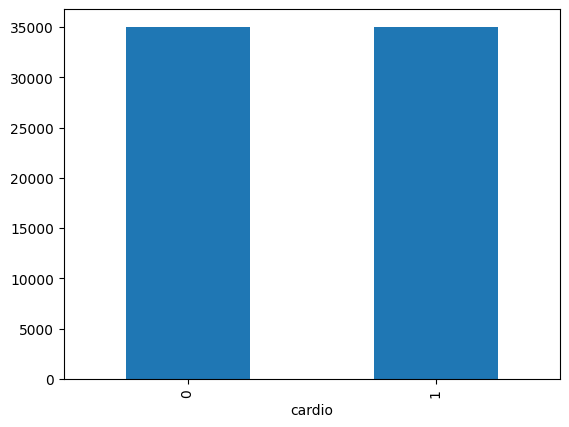

In [160]:
data["cardio"].value_counts().plot(kind = "bar");

In [161]:
# Tras comprobar que no existen valores perdidos analizamos las variables.
# El objetivo es determinar si todas las variables son utiles para la modelizacion.
# Hay una serie de variables que no nos proporcionan informacion.
# Eliminamos esas variables
del data['index']
del data['id']

In [162]:
# La variable "gender" toma valores 1 y 2. La reducimos en una unidad para que tome 0 y 1
data["gender"] = data["gender"] - 1

In [163]:
# Volvemos a visualizar los datos.
data.head(n=10)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,1,168,62.0,110,80,1,1,0,0,1,0
1,20228,0,156,85.0,140,90,3,1,0,0,1,1
2,18857,0,165,64.0,130,70,3,1,0,0,0,1
3,17623,1,169,82.0,150,100,1,1,0,0,1,1
4,17474,0,156,56.0,100,60,1,1,0,0,0,0
5,21914,0,151,67.0,120,80,2,2,0,0,0,0
6,22113,0,157,93.0,130,80,3,1,0,0,1,0
7,22584,1,178,95.0,130,90,3,3,0,0,1,1
8,17668,0,158,71.0,110,70,1,1,0,0,1,0
9,19834,0,164,68.0,110,60,1,1,0,0,0,0


Vemos los valores únicos de las columnas categóricas (Las que tienen menos de, por ejemplo, 15 valores únicos)

In [164]:
for columna in data.columns:
    if len(data[columna].unique()) < 15:
        print(f"Columna {columna} -> Valores únicos {data[columna].unique()}")

Columna gender -> Valores únicos [1 0]
Columna cholesterol -> Valores únicos [1 3 2]
Columna gluc -> Valores únicos [1 2 3]
Columna smoke -> Valores únicos [0 1]
Columna alco -> Valores únicos [0 1]
Columna active -> Valores únicos [1 0]
Columna cardio -> Valores únicos [0 1]


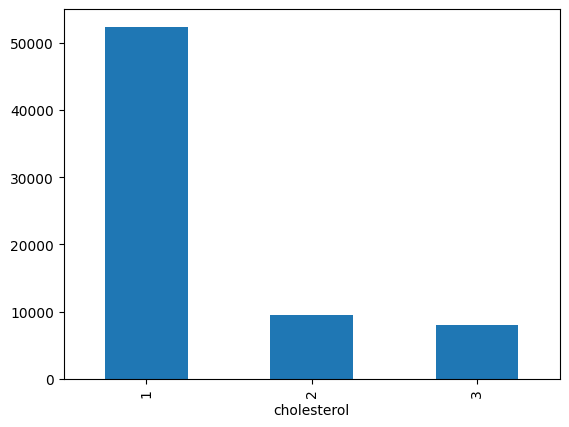

In [165]:
data['cholesterol'].value_counts().plot(kind = "bar");
# Cambio posible
# data['cholesterol'] = data['cholesterol'] != 1

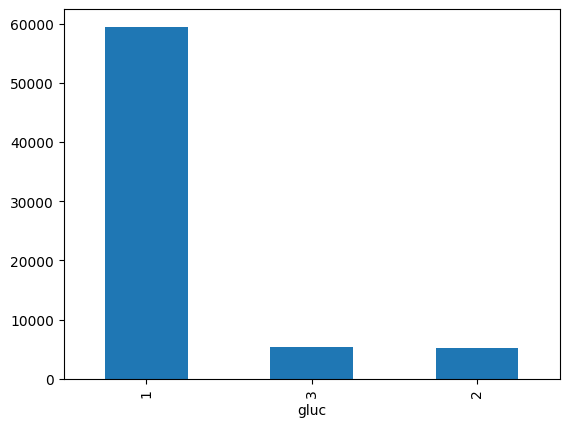

In [166]:
data['gluc'].value_counts().plot(kind = "bar");
# Cambio posible
# data['gluc'] = data['gluc'] != 1

Posteriormente podemos considerar la opción de dumificar o no las columnas `cholesterol`y `gluc`

Ya no hacemos más limpieza en este caso. En este punto lo consideramos "datosfinal"

In [167]:
datos_final = data

## Outliers

### Presión alta

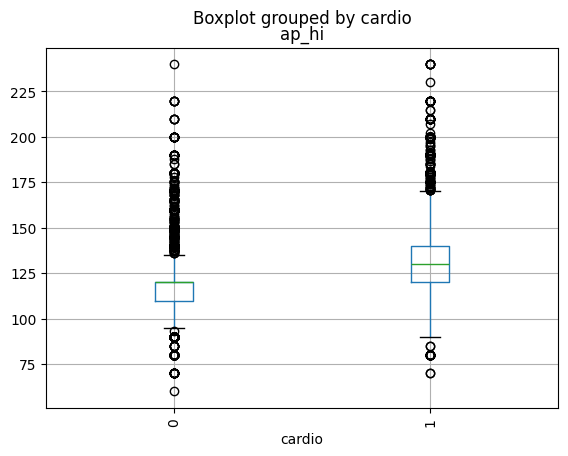

In [168]:
data = data[(data["ap_hi"]<300) & (data["ap_hi"]>50)]
data.boxplot(column="ap_hi", by="cardio", ax=None, fontsize=None, rot=90, grid=True);


### Presión baja

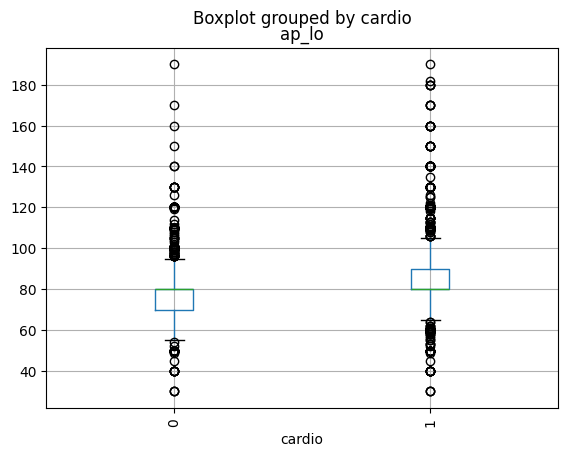

In [169]:
data = data[(data["ap_lo"]<250) & (data["ap_lo"]>25)]
data.boxplot(column="ap_lo", by="cardio", ax=None, fontsize=None, rot=90, grid=True);

In [170]:
data['ap_lo'].value_counts().head(20)

,count
ap_lo,
80,34736
90,14269
70,10218
100,4077
60,2716
110,398
79,357
85,290
75,210


<Axes: title={'center': 'Distribucion de la Tensión arterial'}, ylabel='Density'>

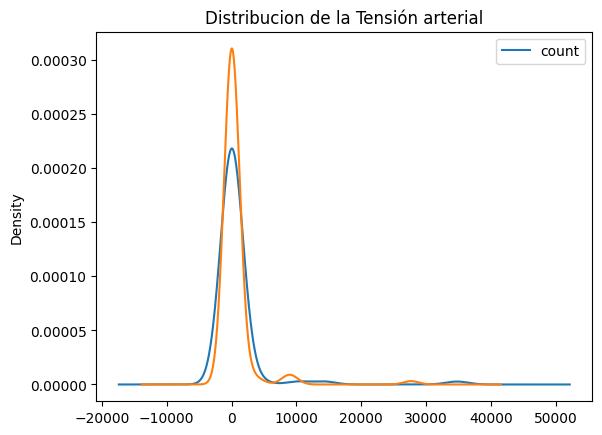

In [171]:
data['ap_lo'].value_counts().sort_index().plot(x='Presión arterial baja',y='frecuencia',
                                           kind='kde', legend=True,title='Distribucion de la Tensión arterial')
data['ap_hi'].value_counts().sort_index().plot(x='Presión arterial alta',y='frecuencia',
                                           kind='kde')

### Alturas Anómalas

Vemos que las personas con altura menor de 125cm tienen pesos exagerados para esa altura. Probablemente se trate de errores en los datos.

In [172]:
data.loc[data["height"]<125, ["height", "weight"]]

,height,weight
224,76,55.0
3420,100,70.0
3735,120,70.0
3752,120,30.0
4212,120,80.0
...,...,...
65302,99,60.0
66023,120,80.0
66479,110,90.0
66643,57,61.0


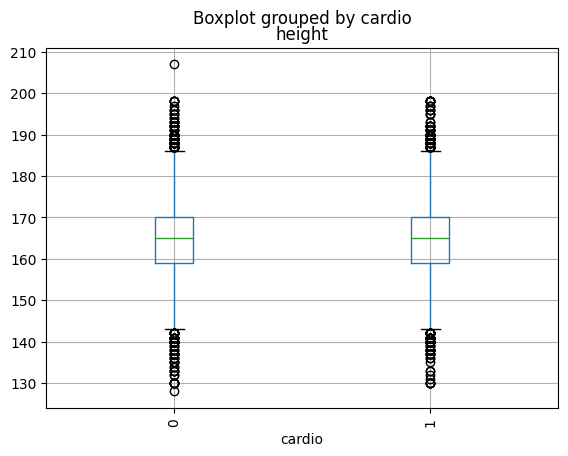

In [173]:
data = data[(data["height"]<220) & (data["height"]>125)]
data.boxplot(column="height", by="cardio", ax=None, fontsize=None, rot=90, grid=True);

### Body Mass Index anómalos

In [174]:
data["BMI"] = (10000 * data["weight"]) / (data["height"] **2)

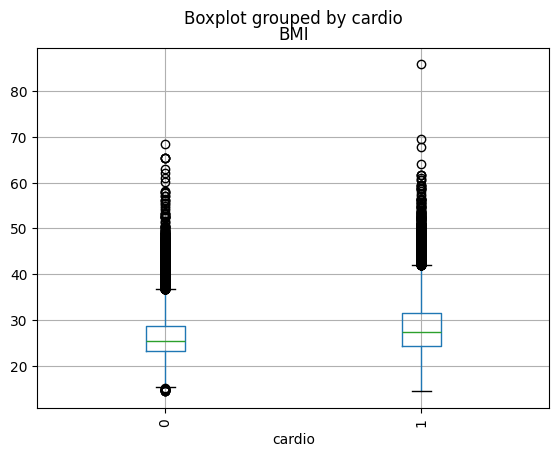

In [175]:
#data = data[data["BMI"]<90]
data = data[data["BMI"]>14]
data.boxplot(column="BMI", by="cardio", ax=None, fontsize=None, rot=90, grid=True);

In [176]:
max(data['BMI'])

85.77974319356386

Text(0, 0.5, 'Frecuencia')

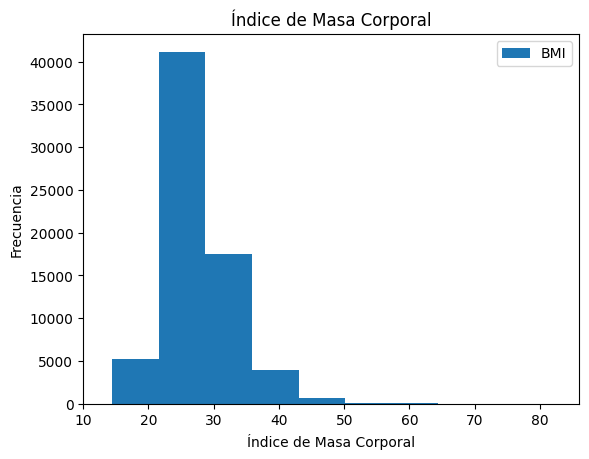

In [177]:
data['BMI'].plot(kind='hist', legend=True, title='Índice de Masa Corporal')

# Ajusta los límites del eje X
plt.xlim(10, 86)

# Configura etiquetas y muestra el gráfico
plt.xlabel('Índice de Masa Corporal')
plt.ylabel('Frecuencia')

In [178]:
data.loc[data["weight"]<40, ["height", "weight", "age", "BMI"]]

,height,weight,age,BMI
5794,151,37.00,17663,16.227358
10447,162,38.00,22007,14.479500
10627,153,37.00,21669,15.805887
11876,157,39.00,17512,15.822143
14722,143,34.00,22663,16.626730
19582,152,38.00,21334,16.447368
22016,146,32.00,15359,15.012197
25198,149,35.45,18768,15.967749
29333,153,37.00,21728,15.805887
31420,140,39.00,20575,19.897959


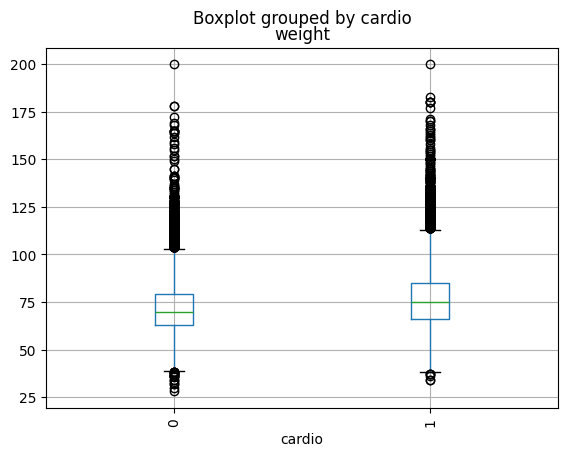

In [179]:
data.boxplot(column="weight", by="cardio", ax=None, fontsize=None, rot=90, grid=True);


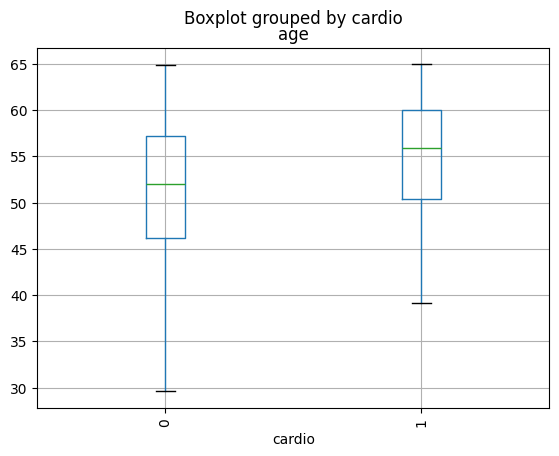

In [180]:
data2 = data
data2["age"] = data2["age"]/365
data2.boxplot(column="age", by="cardio", ax=None, fontsize=None, rot=90, grid=True);

In [181]:
datos_final = data

In [182]:
datos_final = datos_final.reset_index()
datos_final.index

RangeIndex(start=0, stop=68682, step=1)

# Correlación

In [183]:
datos_final.columns

Index(['index', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'BMI'],
      dtype='object')

In [184]:
datos_final = datos_final.drop(columns='index')
datos_final = datos_final.drop(columns='weight')
datos_final = datos_final.drop(columns='height')
datos_final = datos_final.drop(columns='ap_lo')

<Axes: >

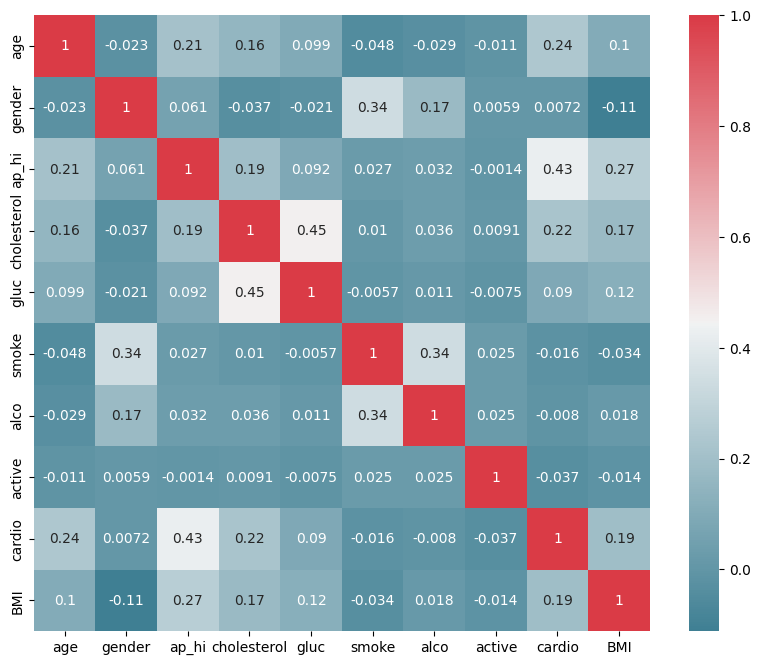

In [185]:
f, ax = plt.subplots(figsize=(10, 8))
corr = datos_final.corr()
sns.heatmap(corr, annot=True, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True, ax=ax)

## Separación Train - Test

Vamos a preparar los datos para entrenar y evaluar los modelos utilizando la biblioteca scikit-learn (sklearn) en Python.

Aquí es lo que está haciendo cada línea:

La función `train_test_split` se utiliza para dividir los datos en conjuntos de entrenamiento y prueba de manera aleatoria.

Podría ser que las condiciones de medida de los registros de mi dataset fueran distintos en la parte baja de la tabla a las condiciones en la parte alta.

Por ello es conveniente "barajar" aleatoriamente las filas.

`random_state=42`: establece una semilla aleatoria para garantizar la reproducibilidad de la división de los datos

In [186]:
from sklearn.model_selection import train_test_split
y = datos_final['cardio']
X = datos_final.drop('cardio', axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#   Regresión Logística

El primer modelo de calsificacion es la regresion logistica. Este modelo es una regresion que mide la probabilidad de que una observacion tome el valor 0 o 1. (Verdadero o falso, acierto o error...)

In [187]:
RegLog = LogisticRegression(C=1.0,
                            class_weight = None,
                            dual=False,
                            fit_intercept=True,
                            intercept_scaling=1,
                            max_iter=100,
                            multi_class='ovr',
                            n_jobs=1,
                            penalty='l2',
                            random_state=None,
                            solver='liblinear',
                            tol=0.0001,
                            verbose=0,
                            warm_start=False)

Documentación: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

"C" es la complejidad del modelo. Cuanto más complejo, más error por "overfitting".<br>
"class_weight" es el peso relativo de una variable respecto de las otras.
- None -> todas mismo peso.
- "balanced" -> inversamente proporcional a la frecuencia de la clase.

In [188]:
# Aplicamos el modelo a los datos de train
RegLog.fit(X_train, y_train)
print(RegLog.feature_names_in_)
RegLog.coef_

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


['age' 'gender' 'ap_hi' 'cholesterol' 'gluc' 'smoke' 'alco' 'active' 'BMI']


array([[ 0.04871464,  0.05610386,  0.05927938,  0.4949896 , -0.1180714 ,
        -0.16883814, -0.19839515, -0.23870759,  0.02936481]])

In [189]:
# Realizamos la prediccion sobre los datos de test
prediccion = RegLog.predict(X_test)

In [190]:
# Comprobamos la precision del modelo con respecto a los datos de testeo.
precision = RegLog.score(X_test, y_test)

In [191]:
precision

0.7222642828023994

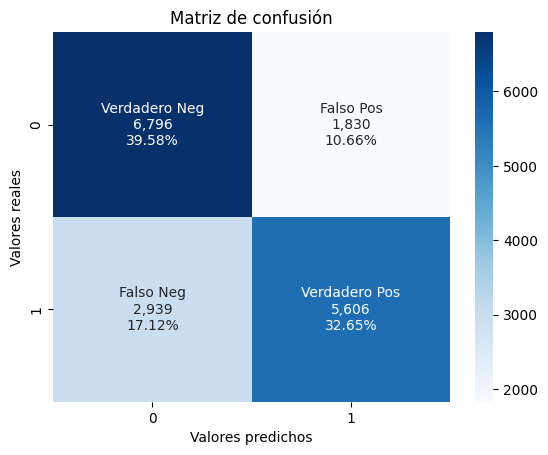

In [192]:
cuadro_matriz_confusion(confusion_matrix(y_test, prediccion))

In [193]:
resumen_metricas(confusion_matrix(y_test, prediccion), y_test)

Precisión (Accuracy): 0.7222642828023994
Sensibilidad (Recall): 0.6560561732007022
Especificidad: 0.7878506839786691
Valor Predictivo Positivo (PPV): 0.7538999462076386


### Diferencia normalizando
Sin normalizar<br>
- Precisión (Accuracy): 0.7235455127831809
- Sensibilidad (Recall): 0.6624926857811586
- Especificidad: 0.7840250405750058
- Valor Predictivo Positivo (PPV): 0.7523923444976076

Normalizando<br>
- Precisión (Accuracy): 0.7233707996039834
- Sensibilidad (Recall): 0.663662960795787
- Especificidad: 0.7825179689311385
- Valor Predictivo Positivo (PPV): 0.7514244070491586

# Curva ROC y AUC para Clasificación

La **Curva ROC (Receiver Operating Characteristic)** y el **AUC (Area Under the Curve)** son herramientas fundamentales para evaluar el rendimiento de modelos de clasificación binaria.

## ¿Qué es la Curva ROC?

La curva ROC es una representación gráfica que muestra:
- En el eje X: La **Tasa de Falsos Positivos (FPR)** = FP / (FP + TN)
- En el eje Y: La **Tasa de Verdaderos Positivos (TPR)** o Sensibilidad = TP / (TP + FN)

La curva se genera variando el umbral de decisión del clasificador desde 0 hasta 1.

## Interpretación de la Curva ROC

- **Diagonal (AUC = 0.5)**: Rendimiento equivalente a adivinar al azar
- **Curva por encima de la diagonal**: Mejor que aleatorio
- **Curva que llega a la esquina superior izquierda (AUC = 1.0)**: Clasificador perfecto

## ¿Qué es el AUC?

El AUC (Area Under the ROC Curve) es una métrica que resume el rendimiento del clasificador:
- **0.5**: No mejor que aleatorio
- **0.7-0.8**: Aceptable
- **0.8-0.9**: Bueno
- **>0.9**: Excelente

## Ventajas del AUC

1. Es invariante a la distribución de clases (funciona bien con clases desbalanceadas)
2. No depende del umbral de clasificación elegido
3. Proporciona una medida única del rendimiento del modelo


## Limitaciones

- Solo mide la capacidad de ordenar las instancias (no la calibración de probabilidades)
- Puede ser demasiado optimista con clases muy desbalanceadas
- No es adecuada para problemas de clasificación multiclase (aunque existen extensiones)

La curva ROC y el AUC son especialmente útiles cuando necesitas comparar diferentes modelos o cuando el costo de los falsos positivos y falsos negativos no está claramente definido.

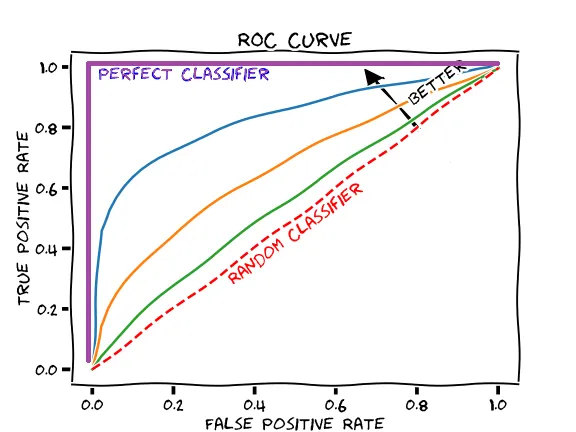

- predict_proba() devuelve probabilidades entre 0 y 1 (ej. 0.23, 0.78, etc.)

- La curva ROC puede evaluar múltiples umbrales (ej. 0.5, 0.6, 0.7...)

- Obtendrás una curva suave con tantos puntos como valores únicos de probabilidad


In [194]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

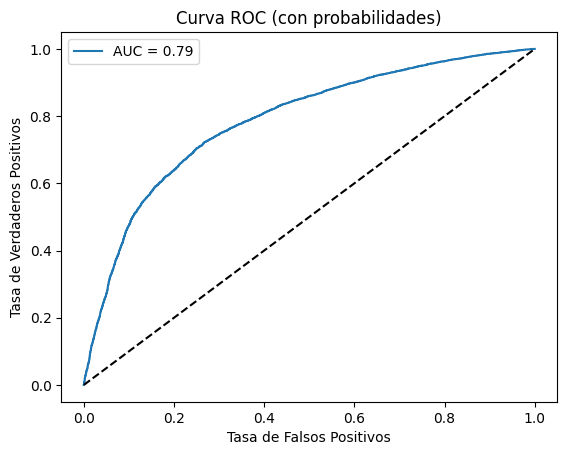

In [195]:
# Obtener las probabilidades predichas (no las clases)
y_scores = RegLog.predict_proba(X_test)[:, 1]  # Probabilidades de la clase positiva

# Ahora calcula la curva ROC con las probabilidades
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

# Gráfico
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC (con probabilidades)')
plt.legend()
plt.show()

# Normalización

In [196]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
datosfinal_sin_columnas = ss.fit_transform(datos_final)
datos_normalizados = pd.DataFrame(datosfinal_sin_columnas, columns = datos_final.columns)
datos_normalizados.head(20)

,age,gender,ap_hi,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,-0.434281,1.366691,-0.991392,-0.537303,-0.395204,-0.310686,-0.238107,0.494639,-0.989860,-1.052610
1,0.309249,-0.731694,0.798271,2.407873,-0.395204,-0.310686,-0.238107,0.494639,1.010244,1.437937
2,-0.246271,-0.731694,0.201717,2.407873,-0.395204,-0.310686,-0.238107,-2.021677,1.010244,-0.756546
3,-0.746280,1.366691,1.394825,-0.537303,-0.395204,-0.310686,-0.238107,0.494639,1.010244,0.243218
4,-0.806654,-0.731694,-1.587946,-0.537303,-0.395204,-0.310686,-0.238107,-2.021677,-0.989860,-0.851980
5,0.992404,-0.731694,-0.394837,0.935285,1.352826,-0.310686,-0.238107,-2.021677,-0.989860,0.372774
6,1.073038,-0.731694,0.201717,2.407873,-0.395204,-0.310686,-0.238107,0.494639,-0.989860,1.976388
7,1.263884,1.366691,0.201717,2.407873,3.100856,-0.310686,-0.238107,0.494639,1.010244,0.487863
8,-0.728046,-0.731694,-0.991392,-0.537303,-0.395204,-0.310686,-0.238107,0.494639,-0.989860,0.191425
9,0.149602,-0.731694,-0.991392,-0.537303,-0.395204,-0.310686,-0.238107,-2.021677,-0.989860,-0.415501


In [197]:
datos_normalizados.isnull().sum()

,0
age,0
gender,0
ap_hi,0
cholesterol,0
gluc,0
smoke,0
alco,0
active,0
cardio,0
BMI,0


## Recuperación de columnas booleanas

In [142]:
datos_normalizados.columns

Index(['age', 'gender', 'ap_hi', 'cholesterol', 'gluc', 'smoke', 'alco',
       'active', 'cardio', 'BMI'],
      dtype='object')

In [204]:
datos_normalizados = datos_normalizados.reset_index(drop=True)
datos_final = datos_final.reset_index()
#datos_normalizados["gender"] = datos_final["gender"]
#datos_normalizados["alco"] = datos_final["alco"]
#datos_normalizados["active"] = datos_final["active"]
datos_normalizados["cardio"] = datos_final["cardio"]

In [205]:
datos_normalizados.isnull().sum()

,0
age,0
gender,0
ap_hi,0
cholesterol,0
gluc,0
smoke,0
alco,0
active,0
cardio,0
BMI,0


In [206]:
datos_normalizados.describe().T

,count,mean,std,min,25%,50%,75%,max
age,68682.0,4.730434e-16,1.000007,-3.511724,-0.732098,0.095712,0.753340,1.721347
gender,68682.0,2.627732e-17,1.000007,-0.731694,-0.731694,-0.731694,1.366691,1.366691
ap_hi,68682.0,1.495945e-16,1.000007,-3.974163,-0.394837,-0.394837,0.798271,6.763814
cholesterol,68682.0,8.048721e-17,1.000007,-0.537303,-0.537303,-0.537303,0.935285,2.407873
gluc,68682.0,1.491807e-16,1.000007,-0.395204,-0.395204,-0.395204,-0.395204,3.100856
smoke,68682.0,2.731185e-17,1.000007,-0.310686,-0.310686,-0.310686,-0.310686,3.218681
alco,68682.0,-6.290003e-17,1.000007,-0.238107,-0.238107,-0.238107,-0.238107,4.199793
active,68682.0,4.138160e-18,1.000007,-2.021677,0.494639,0.494639,0.494639,0.494639
cardio,68682.0,4.949041e-01,0.499978,0.000000,0.000000,0.000000,1.000000,1.000000
BMI,68682.0,2.215985e-16,1.000007,-2.491457,-0.685963,-0.211054,0.513349,11.209849


# K Nearest Neighbours

Una vez que tenemos los datos normalizados y sin normalizar los utilizaremos para los proximos modelos

Creamos el modelo

Documentación: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [207]:
knn = KNeighborsClassifier(algorithm='auto',
                           leaf_size=30,
                           metric='minkowski',
                           metric_params=None,
                           n_jobs=1,
                           n_neighbors=5,
                           p=2,
                           weights='uniform')

In [208]:
from sklearn.model_selection import train_test_split
y = datos_normalizados['cardio']
X = datos_normalizados.drop('cardio', axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [209]:
# Entrenamiento
knn.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=1)

In [210]:
# Realizamos la prediccion sobre los datos de test
prediccion = knn.predict(X_test)

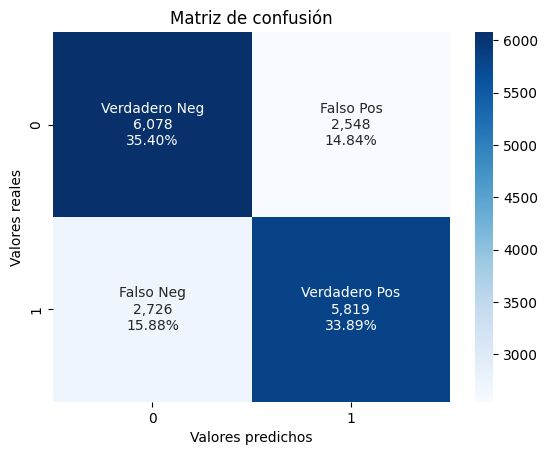

In [211]:
# Calculamos el nivel de acierto entre lo predicho y el test
cuadro_matriz_confusion(confusion_matrix(y_test, prediccion))

In [212]:
resumen_metricas(confusion_matrix(y_test, prediccion), y_test)

Precisión (Accuracy): 0.6928542309708229
Sensibilidad (Recall): 0.6809830310122879
Especificidad: 0.704613957801994
Valor Predictivo Positivo (PPV): 0.6954702999880483


Resultados Regr Logística son mejores en todas las métricas

Sin normalizar<br>
- Precisión (Accuracy): 0.7235455127831809
- Sensibilidad (Recall): 0.6624926857811586
- Especificidad: 0.7840250405750058
- Valor Predictivo Positivo (PPV): 0.7523923444976076

# Naïve Bayes

Documentación: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html

In [213]:
gnb = GaussianNB()

In [214]:
Bayes = gnb.fit(X_train, y_train)

In [215]:
prediccion = gnb.predict(X_test)

In [216]:
accuracy_score(y_test, prediccion)

0.6923883291596296

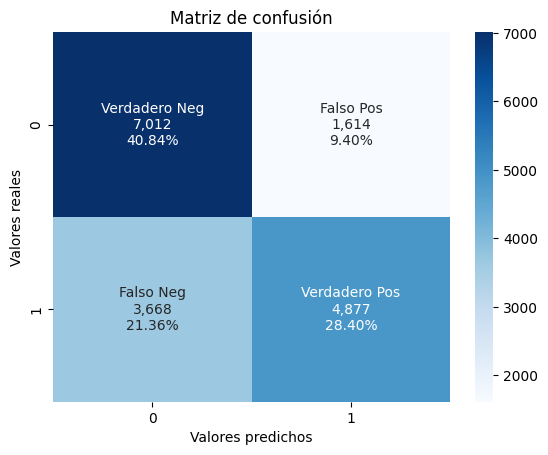

In [217]:
# Calculamos el nivel de acierto entre lo predicho y el test
cuadro_matriz_confusion(confusion_matrix(y_test, prediccion))

In [218]:
resumen_metricas(confusion_matrix(y_test, prediccion), y_test)

Precisión (Accuracy): 0.6923883291596296
Sensibilidad (Recall): 0.5707431246342891
Especificidad: 0.8128912589844656
Valor Predictivo Positivo (PPV): 0.7513480203358497


Resultados Regr Logística son mejores en todas las métricas

Sin normalizar<br>
- Precisión (Accuracy): 0.7235455127831809
- Sensibilidad (Recall): 0.6624926857811586
- Especificidad: 0.7840250405750058
- Valor Predictivo Positivo (PPV): 0.7523923444976076

# Árbol de decisión

Documentación: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.tree

In [219]:
modelo = tree.DecisionTreeClassifier(class_weight=None,
                                     criterion='gini',
                                     max_depth=3,
                                     max_features=None,
                                     max_leaf_nodes=None,
                                     min_impurity_decrease=0.0,
                                     min_samples_leaf=1,
                                     min_samples_split=2,
                                     min_weight_fraction_leaf=0.0,
                                     random_state=None,
                                     splitter='best')


- Criterion: Algoritmo de decisión.
- Splitter: Con Best elegimos la divisiÃ³n que mejor separa los datos segÃºn el objetivo en cada nivel de bajada. La alternativa es "random"
- Max_depth: Se puede probar menos niveles e ir aumentando.

Ajuste del modelo a partir de los datos de entrenamiento

In [220]:
arbol = modelo.fit(X_train, y_train)

In [221]:
prediccion = arbol.predict(X_test)

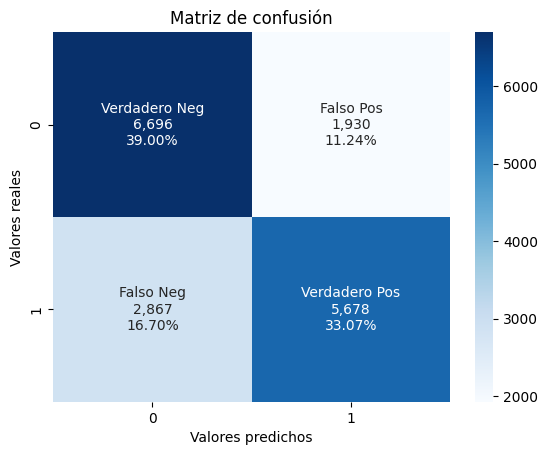

In [222]:
# Calculamos el nivel de acierto entre lo predicho y el test
cuadro_matriz_confusion(confusion_matrix(y_test, prediccion))

In [223]:
resumen_metricas(confusion_matrix(y_test, prediccion), y_test)

Precisión (Accuracy): 0.7206336264632228
Sensibilidad (Recall): 0.6644821533060269
Especificidad: 0.7762578251796893
Valor Predictivo Positivo (PPV): 0.7463196635120926


Resultados Regr Logística son peores en todas las métricas

Sin normalizar<br>
- Precisión (Accuracy): 0.7235455127831809
- Sensibilidad (Recall): 0.6624926857811586
- Especificidad: 0.7840250405750058
- Valor Predictivo Positivo (PPV): 0.7523923444976076

In [224]:
importanciasarbol = pd.DataFrame(arbol.feature_importances_)
importanciasarbol.index = (X.columns)
print(importanciasarbol)

                    0
age          0.095719
gender       0.000000
ap_hi        0.828010
cholesterol  0.076271
gluc         0.000000
smoke        0.000000
alco         0.000000
active       0.000000
BMI          0.000000


También puedo obtener una representación gráfica de las separaciones de los datos realizadas por el árbol de decisión en función de los valores de corte.

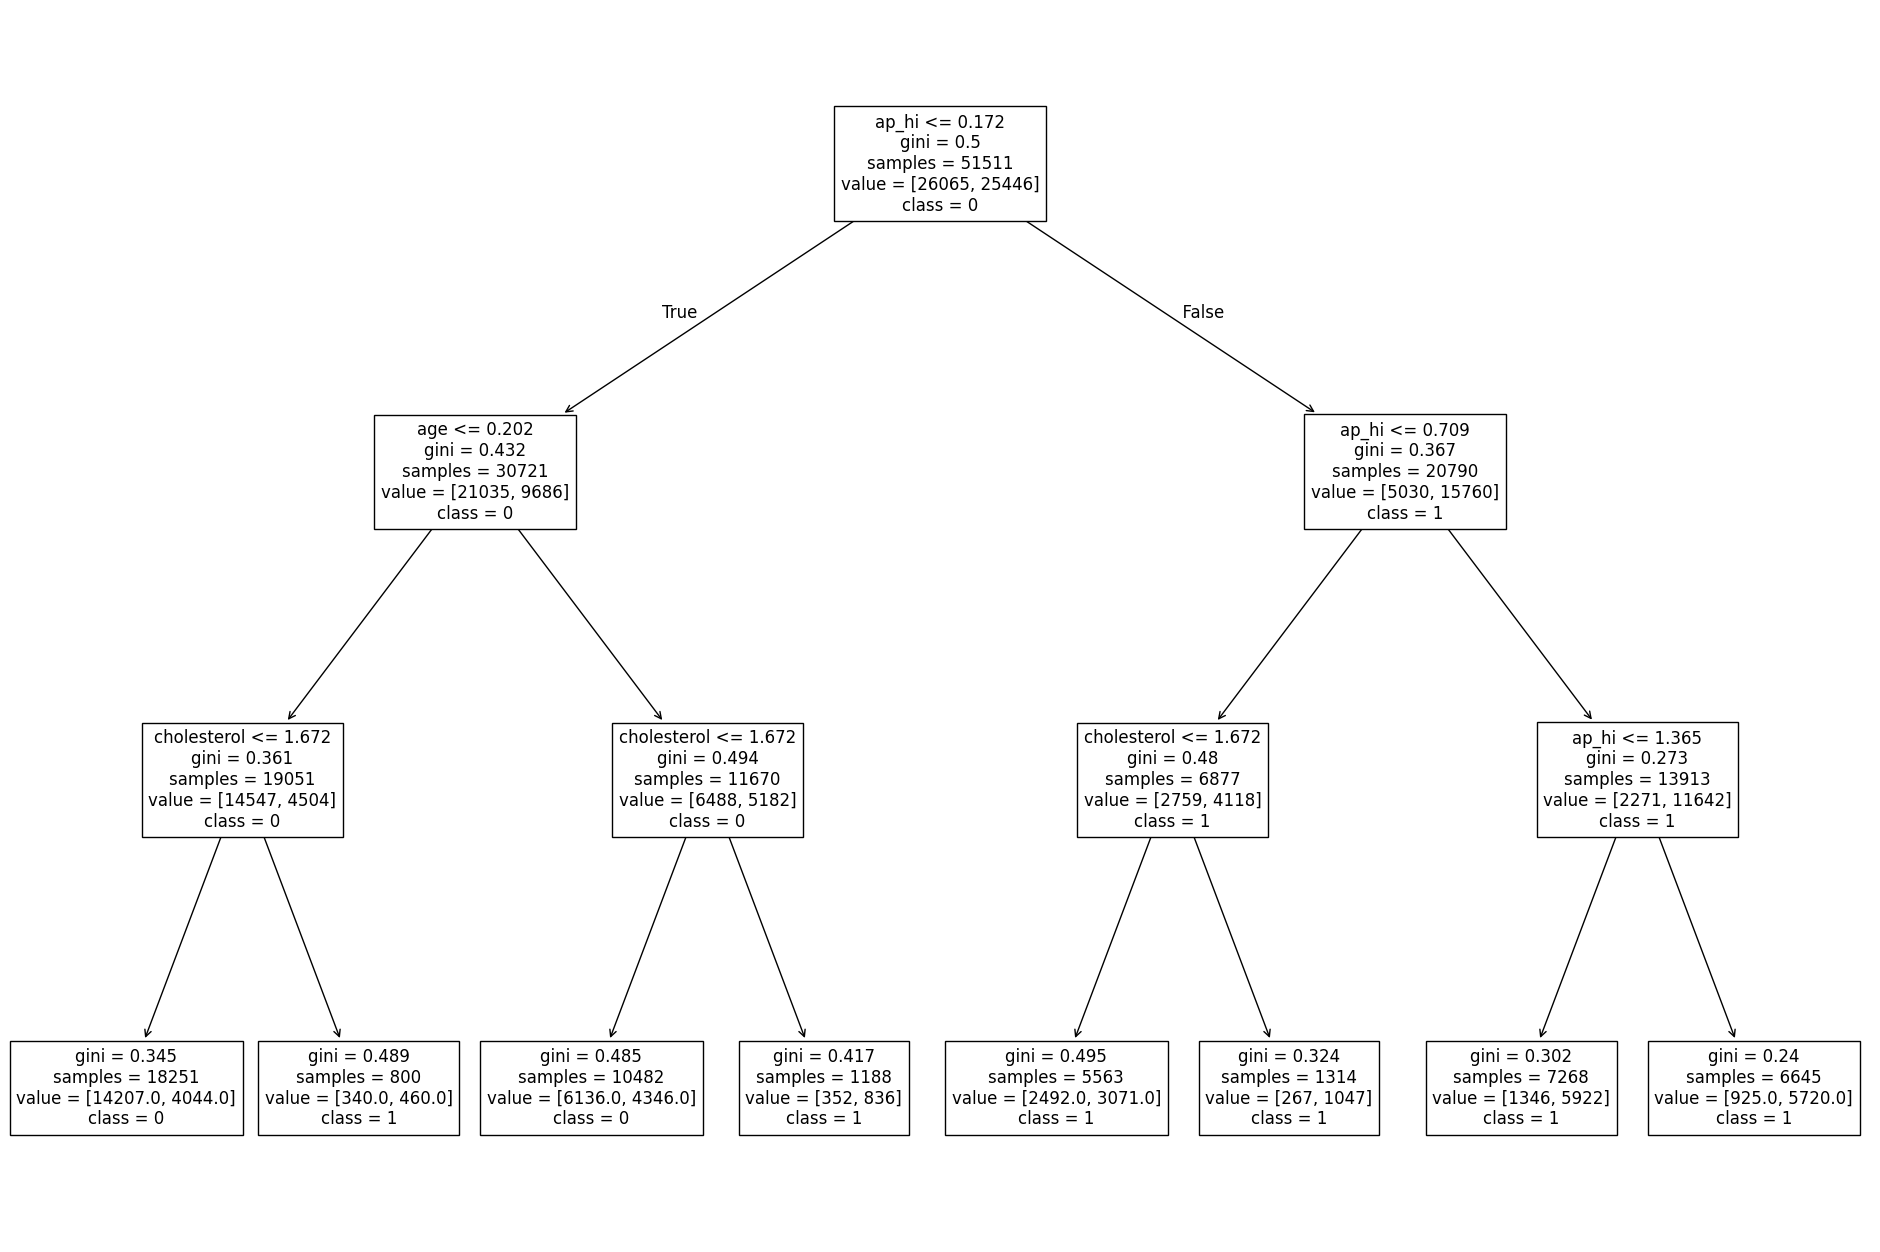

In [225]:
plt.figure(figsize=(24,16))

tree.plot_tree(arbol.fit(X_train, y_train), feature_names=X.columns,
               class_names=['0', '1'], filled=False);

# XGBoost

XGBoost (eXtreme Gradient Boosting) es un algoritmo de aprendizaje automático supervisado basado en árboles de decisión que ha ganado mucha popularidad en los últimos años.<br>

Algunas de las principales características y ventajas de XGBoost son:

**Rendimiento superior:** XGBoost ha demostrado resultados de estado del arte en una gran variedad de problemas de machine learning, superando a otros algoritmos en muchas competiciones.

**Flexibilidad:** Puede manejar una variedad de tipos de datos y tareas de predicción, incluyendo clasificación, regresión y ranking. Admite personalización, permitiendo a los usuarios definir sus propias funciones de objetivo y evaluación.

**Manejo inteligente de datos faltantes:** XGBoost tiene una forma inteligente de manejar los datos faltantes, permitiendo construir modelos precisos incluso cuando los datos son incompletos.

**Escalabilidad y paralelización**: XGBoost puede escalar a grandes conjuntos de datos y es compatible con una variedad de plataformas. Además, permite el procesamiento paralelo utilizando múltiples núcleos de CPU o incluso GPUs, lo que acelera significativamente el entrenamiento.

Documentación: https://xgboost.readthedocs.io/en/latest/python/python_api.html

In [226]:
import xgboost as xgb
# conda install -c anaconda py-xgboost

In [227]:
modelo = xgb.XGBClassifier(base_score=0.5,
                           colsample_bylevel=1,
                           colsample_bytree=1,
                           gamma=0,
                           learning_rate=0.001,
                           max_delta_step=0,
                           max_depth=5,
                           min_child_weight=1,
                           missing=1,
                           n_estimators=1500,
                           objective='binary:logistic',
                           reg_alpha=0,
                           reg_lambda=1,
                           scale_pos_weight=1,
                           seed=0,
                           verbosity=0,
                           subsample=1)

In [228]:
XGBoost = modelo.fit(X_train, y_train)
prediccion = XGBoost.predict(X_test)
print(f"Precisión de train {accuracy_score(y_train, XGBoost.predict(X_train))}")
print(f"Precisión de test {accuracy_score(y_test, prediccion)}")

Precisión de train 0.7353380831278756
Precisión de test 0.7302428513190845


In [229]:
confusion = confusion_matrix(y_test, prediccion)

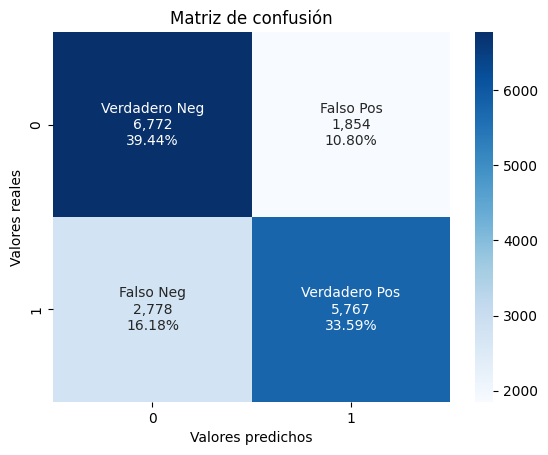

In [230]:
cuadro_matriz_confusion(confusion)

In [231]:
resumen_metricas(confusion, y_test)

Precisión (Accuracy): 0.7302428513190845
Sensibilidad (Recall): 0.67489760093622
Especificidad: 0.785068397866914
Valor Predictivo Positivo (PPV): 0.7567248392599396


Modelo del Árbol de decisión da mayor sensibilidad. El resto, peor:
- Precisión (Accuracy): 0.726107972744744
- Sensibilidad (Recall): 0.7130485664131071
- Especificidad: 0.739044748434964
- Valor Predictivo Positivo (PPV): 0.7302253116011506

Resultados Regr Logística son peores en todas las métricas

Sin normalizar<br>
- Precisión (Accuracy): 0.7235455127831809
- Sensibilidad (Recall): 0.6624926857811586
- Especificidad: 0.7840250405750058
- Valor Predictivo Positivo (PPV): 0.7523923444976076

In [232]:
#cross_val_score(XGBoost, X, y, cv=10)
cross_val_score(XGBoost, X, y, cv=10, scoring='precision')
#cross_val_score(XGBoost, X, y, cv=10, scoring='recall')

array([0.74812153, 0.74126534, 0.76382563, 0.75638952, 0.75064935,
       0.75062893, 0.75016393, 0.7605588 , 0.74618321, 0.74757282])

También con XGBoost puedo obtener una medida de la importancia de las características a la hora de decidir si esa característica es clave o no para tener una enfermedad coronaria

In [233]:
importanciasxgb = pd.DataFrame(XGBoost.feature_importances_)
importanciasxgb.index = (X.columns)
importanciasxgb

,0
age,0.082215
gender,0.001858
ap_hi,0.760814
cholesterol,0.087733
gluc,0.010385
smoke,0.008641
alco,0.007274
active,0.027262
BMI,0.013818
